# Problem 3: Laminar Flow
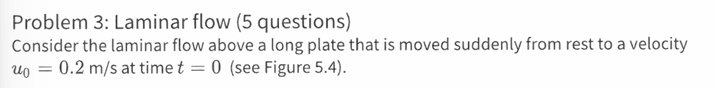

In [8]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation
from math import erfc
from scipy.special import erfc, erfcinv

In [9]:
u_0 = 0.2                   # Plate velocity amplitude [m/s]
viscosity = 1.3*10**-6      # Kinematic viscosity [m2/s]
rho_water = 1000            # density of water (kg/m^3)

### Question 3.1
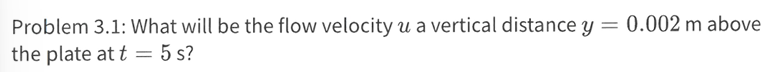
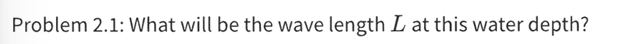

In [10]:
# Stokes velocity profile after sudden start of a plate
y1 = 0.002                    # Distance from the plate [m]
t1 = 5                      # Time after the start of oscillation [s]

y_arr = np.asarray(y1, dtype=float)
denom = 2.0 * np.sqrt(viscosity * t1)
xi = y_arr / denom
erfc_v = np.vectorize(erfc)
u = u_0 * erfc_v(xi)        # P8 eq. 5.32 p.9
print(f"Flow velocity at y={y1} m and t={t1} s: {u:.2f} m/s")

Flow velocity at y=0.002 m and t=5 s: 0.12 m/s


### Question 3.2
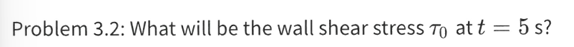
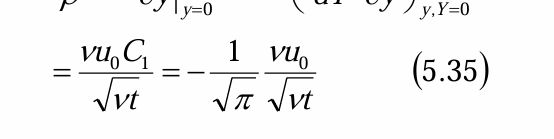
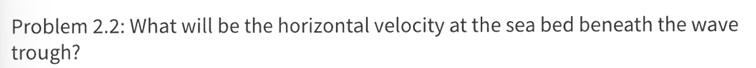

In [11]:
wall_shear_stress = -1/np.sqrt(np.pi) * viscosity * u_0 / (np.sqrt(viscosity * t1)) * rho_water  # [Pa] P8 eq. 5.35 p.10

print(f"Shear stress at the plate τ = {wall_shear_stress:.3f} Pa")

Shear stress at the plate τ = -0.058 Pa


### Question 3.3
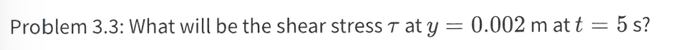
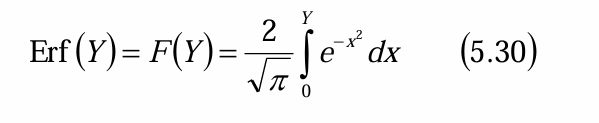
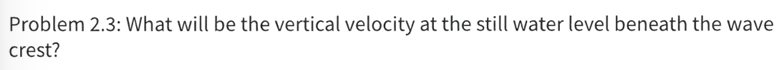

In [12]:
eta = y1 / (2 * np.sqrt(viscosity * t1))  # Dimensionless distance Y = y / (2√(νt))

du_dy = -u_0 / np.sqrt(np.pi * viscosity * t1) * np.exp(-eta**2) # Velocity gradient du/dy at y1 in the figure above

tau = rho_water * viscosity * du_dy # Shear stress at y1

print(f"Shear stress at y={y1}: {tau:.3f} Pa")


Shear stress at y=0.002: -0.049 Pa


### Question 3.4
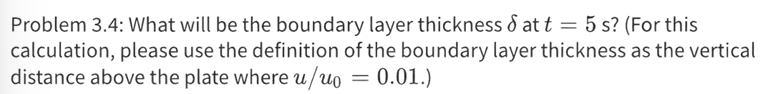
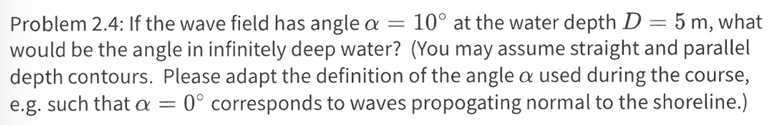

In [13]:
delta = 3.64 * np.sqrt(viscosity * t1)  # Boundary layer thickness [m] P8 eq. 5.33 p.9

print(f"Boundary layer thickness at t={t1} s: {delta:.4f} m")

Boundary layer thickness at t=5 s: 0.0093 m


### Question 3.5
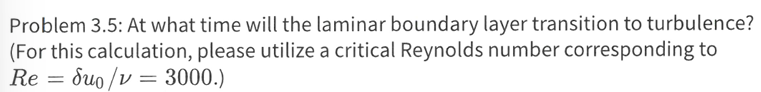
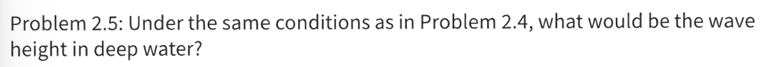

In [14]:
# Critical Reynolds number for transition
Re_crit = 3000.0          

# δ from critical Reynolds number -> Re = delta * u_0 / viscosity
delta = Re_crit * viscosity / u_0   # m

# Formula for the exact solution of the suddenly-moved-plate problem u/u0 = erfc(y / (2 * sqrt(viscosity * t)))
# η solves erfc(η) = 0.01 because u/u0 = erfc(η) and we use u/u0 = 0.01 at y = δ
y = erfcinv(0.01)

# solve for t: δ = 2 * η * sqrt(nu * t)  =>  t = (δ / (2 η))^2 / nu
t_transition = (delta / (2.0 * y))**2 / viscosity



print(f"Transition time t = {t_transition:.0f} s")

Transition time t = 22 s
